In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


# Data Preparation

In [30]:
#Load Data      
data = pd.read_csv('Mall_Customer.csv')

In [31]:
#Target Klasifikasi (-1 dan +1)
# Age < 40, Muda = 1
# Age > 40, Tua = -1
data['Target'] = np.where(data['Age'] < 40, 1, -1)

In [32]:
#Ekstrak fitur X dan Y
x = data[['Annual Income (k$)', 'Spending Score (1-100)']].values
y = data['Target'].values

In [33]:
#split data menjadi 80 train dan 20 test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

In [34]:
# standardisasi data
scaler = StandardScaler()
x_train_standard = scaler.fit_transform(x_train)
x_test_standard = scaler.transform(x_test)

# Implementasi Perceptron

In [ ]:
def train_perceptron(X, y, learning_rate=0.01, epochs=50):
    # Set bobot dan bias
    # x = Gaji dan Skor Spending
    # y = target -1 / 1
    # w = bobot
    # b = bias
    w = np.zeros(X.shape[1])
    b = 0.0
    errors_per_epoch = []
    
    for epoch in range(epochs):
        errors = 0
        for xi, yi in zip(X, y):
            # Hitung output
            z = np.dot(w, xi) + b
            y_hat = 1 if z >= 0 else -1
            # Fungsi Aktivasi Bipolar Step (y_hat)
                        
            # Hitung error dan update jika salah klasifikasi
            if yi != y_hat:
                delta = learning_rate * (yi - y_hat)
                w += delta * xi
                b += delta
                errors += 1
        
        errors_per_epoch.append(errors)
        # Early stopping jika sudah konvergen (0 error)
        if errors == 0:
            break
            
    return w, b, errors_per_epoch

In [64]:
def predict_perceptron(X, w, b):
    z = np.dot(X, w) + b
    return np.where(z >= 0, 1, -1)

In [65]:
# Latih model
w_perc, b_perc, error_perc = train_perceptron(x_train_standard, y_train, learning_rate=0.01, epochs=50)

# Uji model
y_pred_perc = predict_perceptron(x_test_standard, w_perc, b_perc)

In [68]:
# Output Perceptron
acc_perc = accuracy_score(y_test, y_pred_perc)
print("=== HASIL PERCEPTRON ===")
print(f"Bobot akhir (w): {w_perc}")
print(f"Bias akhir (b): {b_perc:.4f}")
print(f"Total error klasifikasi di Epoch 50: {error_perc[-1]}")
print(f"Akurasi Data Uji (Test): {acc_perc * 100:.2f}%\n")

=== HASIL PERCEPTRON ===
Bobot akhir (w): [ 0.00155284 -0.00173722]
Bias akhir (b): 0.0200
Total error klasifikasi di Epoch 50: 58
Akurasi Data Uji (Test): 57.50%



Diatas dapat kita lihat dari hasil Perceptron yang di train dengan 160 Baris data. Ketika kita test dengan 40 Baris data menghasilkan output:
- Nilai Bias melebihi bobot akhirnya yang artinya kelas Muda (+1) akan lebih terklasifikasi dengan mudah
- Error di klasifikasi Epoch sebanyak 58 sampel pelanggan yang salah ditebak kelasnya 
- Dari 40 baris Test, Perceptron berhasil mencapai Akurasi 57.50% yang artinya 23 data dengan benar.


# Implementasi ADALINE

In [ ]:
def train_adaline(X, y, learning_rate=0.01, epochs=50):
    # n = pembagi rata-rata (saat hitung gradian & MSE) 
    n = X.shape[0]
    # Inisialisasi bobot dan bias dengan nol
    w = np.zeros(X.shape[1])
    b = 0.0
    mse_per_epoch = []
    
    for epoch in range(epochs):
        # Hitung keluaran linear (z) untuk seluruh batch
        # Luarannya angka rill kontinu
        z = np.dot(X, w) + b
        
        # Hitung error linear (selisih linear antara target y dengan x)
        e = y - z
        
        # Update parameter menggunakan Batch Gradient Descent
        # X.T = transpose matriks fitur
        w += learning_rate * (np.dot(X.T, e) / n)
        #Perbarui bias dengan rata-rata seluruh error linear batch
        b += learning_rate * np.mean(e)
        
        # Hitung dan catat fungsi objektif MSE
        mse = (1 / n) * np.sum(e**2)
        mse_per_epoch.append(mse)
        
    return w, b, mse_per_epoch

In [70]:
def predict_adaline(X, w, b):
    # Ambang (threshold) dipasang hanya saat prediksi kelas akhir
    z = np.dot(X, w) + b
    return np.where(z >= 0, 1, -1)

In [71]:
w_adal, b_adal, mse_adal = train_adaline(x_train_standard, y_train, learning_rate=0.01, epochs=50)

# Uji model
y_pred_adal = predict_adaline(x_test_standard, w_adal, b_adal)

In [72]:
# ADALINE
acc_adal = accuracy_score(y_test, y_pred_adal)
print("=== HASIL ADALINE ===")
print(f"Bobot akhir (w): {w_adal}")
print(f"Bias akhir (b): {b_adal:.4f}")
print(f"MSE di Epoch 50: {mse_adal[-1]:.4f}")
print(f"Akurasi Data Uji (Test): {acc_adal * 100:.2f}%")

=== HASIL ADALINE ===
Bobot akhir (w): [0.02614186 0.17329555]
Bias akhir (b): 0.0642
MSE di Epoch 50: 0.8601
Akurasi Data Uji (Test): 60.00%


Diatas dapat kita lihat dari hasil ADALINE yang di train dengan 160 Baris data. Ketika kita test dengan 40 Baris data menghasilkan output:
- Dapat dilihat juga bahwa nilai w2 (Spending Score) yaitu bobot 0, 17329555 lebih besar dibanding w1 (Annual Income). 
- Membuktikan bahwa Spending Score adalah faktor yang jauh lebih dominan
- Dari 40 baris Test, ADALINE berhasil mencapai Akurasi 60% yang artinya 24 data dengan benar.


# Kurva Eror Perceptron & ADALINE

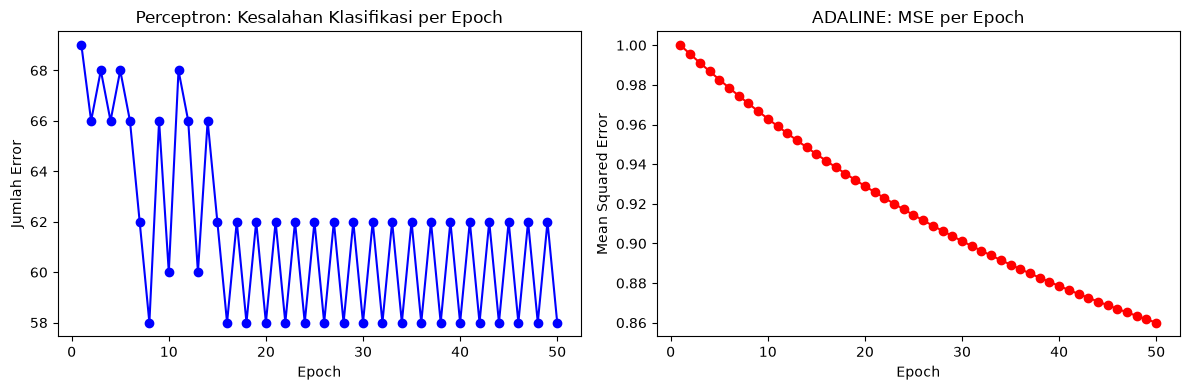

In [43]:
# Visualisasi Kurva Error
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Kurva Perceptron
axes[0].plot(range(1, len(error_perc) + 1), error_perc, marker='o', color='blue')
axes[0].set_title('Perceptron: Kesalahan Klasifikasi per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Jumlah Error')

# Kurva ADALINE
axes[1].plot(range(1, len(mse_adal) + 1), mse_adal, marker='o', color='red')
axes[1].set_title('ADALINE: MSE per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Squared Error')

plt.tight_layout()
plt.show()

# Grafik Decision Boundary

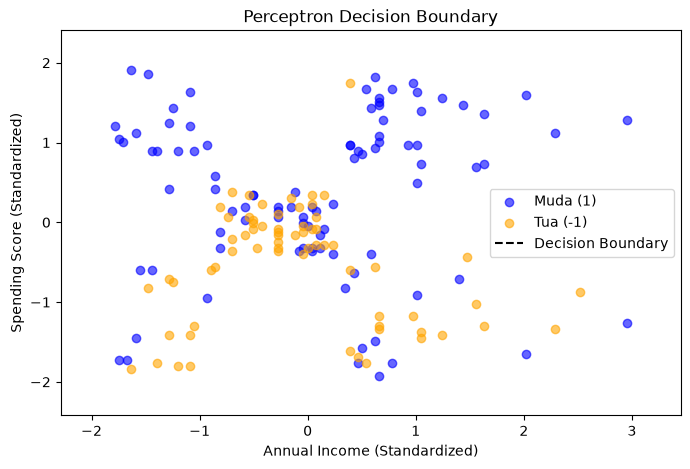

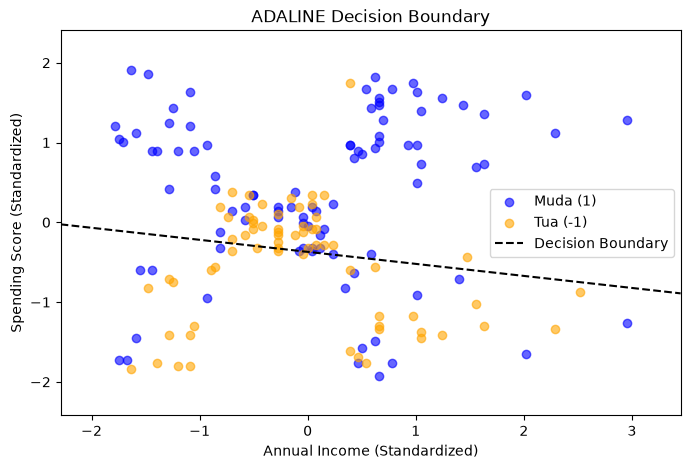

In [44]:
# Fungsi untuk menggambar garis Decision Boundary
def plot_decision_boundary(X, y, w, b, title):
    plt.figure(figsize=(8, 5))
    
    # Plot titik data asli
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Muda (1)', alpha=0.6)
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='orange', label='Tua (-1)', alpha=0.6)
    
    # Menghitung koordinat garis pembatas (w1*x1 + w2*x2 + b = 0)
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Mencegah error jika w[1] bernilai 0
    if w[1] != 0:
        x1_vals = np.array([x1_min, x1_max])
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        plt.plot(x1_vals, x2_vals, color='black', linestyle='--', label='Decision Boundary')
    
    plt.xlim(x1_min, x1_max)
    plt.ylim(x2_min, x2_max)
    plt.title(title)
    plt.xlabel('Annual Income (Standardized)')
    plt.ylabel('Spending Score (Standardized)')
    plt.legend()
    plt.show()

# Panggil fungsi untuk menggambar grafik
plot_decision_boundary(x_train_standard, y_train, w_perc, b_perc, 'Perceptron Decision Boundary')
plot_decision_boundary(x_train_standard, y_train, w_adal, b_adal, 'ADALINE Decision Boundary')

# Eksperimen Learning Rate (0,001; 0,01; 0,1)

In [45]:
# Siapkan list untuk menyimpan hasil eksperimen
learning_rates = [0.001, 0.01, 0.1]
results = []

In [46]:
# EKSPERIMEN DENGAN STANDARDISASI (6 Konfigurasi)
for lr in learning_rates:
    # Perceptron
    w_p, b_p, err_p = train_perceptron(x_train_standard, y_train, learning_rate=lr, epochs=50)
    acc_p = accuracy_score(y_test, predict_perceptron(x_test_standard, w_p, b_p))
    results.append({'Model': 'Perceptron', 'LR': lr, 'Standardisasi': 'Ya', 
                    'Akurasi Uji': f"{acc_p*100:.2f}%", 'Error / MSE Akhir': round(err_p[-1], 4)})
    
    # ADALINE
    w_a, b_a, mse_a = train_adaline(x_train_standard, y_train, learning_rate=lr, epochs=50)
    acc_a = accuracy_score(y_test, predict_adaline(x_test_standard, w_a, b_a))
    results.append({'Model': 'ADALINE', 'LR': lr, 'Standardisasi': 'Ya', 
                    'Akurasi Uji': f"{acc_a*100:.2f}%", 'Error / MSE Akhir': round(mse_a[-1], 4)})

In [47]:
# EKSPERIMEN TANPA STANDARDISASI (2 Konfigurasi) 
lr_no_std = 0.01

# Perceptron (pakai x_train dan x_test asli)
w_p_no, b_p_no, err_p_no = train_perceptron(x_train, y_train, learning_rate=lr_no_std, epochs=50)
acc_p_no = accuracy_score(y_test, predict_perceptron(x_test, w_p_no, b_p_no))
results.append({'Model': 'Perceptron', 'LR': lr_no_std, 'Standardisasi': 'Tidak', 
                'Akurasi Uji': f"{acc_p_no*100:.2f}%", 'Error / MSE Akhir': round(err_p_no[-1], 4)})

# ADALINE (pakai x_train dan x_test asli)
w_a_no, b_a_no, mse_a_no = train_adaline(x_train, y_train, learning_rate=lr_no_std, epochs=50)
acc_a_no = accuracy_score(y_test, predict_adaline(x_test, w_a_no, b_a_no))
results.append({'Model': 'ADALINE', 'LR': lr_no_std, 'Standardisasi': 'Tidak', 
                'Akurasi Uji': f"{acc_a_no*100:.2f}%", 'Error / MSE Akhir': round(mse_a_no[-1], 4)})

In [48]:
# TAMPILKAN TABEL ---
df_results = pd.DataFrame(results)
display(df_results)

,Model,LR,Standardisasi,Akurasi Uji,Error / MSE Akhir
0,Perceptron,0.001,Ya,57.50%,5.800000e+01
1,ADALINE,0.001,Ya,60.00%,9.791000e-01
2,Perceptron,0.010,Ya,57.50%,5.800000e+01
3,ADALINE,0.010,Ya,60.00%,8.601000e-01
4,Perceptron,0.100,Ya,57.50%,5.800000e+01
5,ADALINE,0.100,Ya,60.00%,7.776000e-01
6,Perceptron,0.010,Tidak,65.00%,8.200000e+01
7,ADALINE,0.010,Tidak,42.50%,3.690355e+178


Dari output diatas bisa kita analisis terkait output:
- Pada Perceptron yang di standardisasi selalu memiliki akurasi 57.50% dan eror akhir yang sama. Karena awal bobot & bias = 0. Jadi nilai learning rate diubah gaakan ngefek.
- Pada ADALINE dengan standardisasi sama juga akurasi nya stabil 60% terus, tetapi MSE menurun seiring Learning Rate membesar. Karena Learning rate yang lebih besar bikin langkah penurunan gradien lebih panjang pada tiap epoch
- ADALINE tanpa standardisasi langsung jelek akurasi dan MSE nya. 
- Perceptron tanpa standardisasi juga memburuk untuk Errornya yang sangat tinggi

# Confusion Matrix

In [54]:
from sklearn.metrics import confusion_matrix, classification_report

print("CONFUSION MATRIX: PERCEPTRON")
cm_perc = confusion_matrix(y_test, y_pred_perc, labels=[1, -1])
print(f"Benar tebak Muda (1) : {cm_perc[0][0]} | Salah tebak jadi Tua (-1): {cm_perc[0][1]}")
print(f"Salah tebak jadi Muda (1): {cm_perc[1][0]} | Benar tebak Tua (-1) : {cm_perc[1][1]}")
print("\nLaporan Klasifikasi Perceptron:")
print(classification_report(y_test, y_pred_perc, labels=[1, -1], target_names=['Muda (1)', 'Tua (-1)'], zero_division=0))

CONFUSION MATRIX: PERCEPTRON
Benar tebak Muda (1) : 23 | Salah tebak jadi Tua (-1): 0
Salah tebak jadi Muda (1): 17 | Benar tebak Tua (-1) : 0

Laporan Klasifikasi Perceptron:
              precision    recall  f1-score   support

    Muda (1)       0.57      1.00      0.73        23
    Tua (-1)       0.00      0.00      0.00        17

    accuracy                           0.57        40
   macro avg       0.29      0.50      0.37        40
weighted avg       0.33      0.57      0.42        40



In [53]:
print("\n CONFUSION MATRIX: ADALINE")
cm_adal = confusion_matrix(y_test, y_pred_adal, labels=[1, -1])
print(f"Benar tebak Muda (1) : {cm_adal[0][0]} | Salah tebak jadi Tua (-1): {cm_adal[0][1]}")
print(f"Salah tebak jadi Muda (1): {cm_adal[1][0]} | Benar tebak Tua (-1) : {cm_adal[1][1]}")
print("\nLaporan Klasifikasi ADALINE:")
print(classification_report(y_test, y_pred_adal, labels=[1, -1], target_names=['Muda (1)', 'Tua (-1)'], zero_division=0))


 CONFUSION MATRIX: ADALINE
Benar tebak Muda (1) : 16 | Salah tebak jadi Tua (-1): 7
Salah tebak jadi Muda (1): 9 | Benar tebak Tua (-1) : 8

Laporan Klasifikasi ADALINE:
              precision    recall  f1-score   support

    Muda (1)       0.64      0.70      0.67        23
    Tua (-1)       0.53      0.47      0.50        17

    accuracy                           0.60        40
   macro avg       0.59      0.58      0.58        40
weighted avg       0.59      0.60      0.60        40

